# visibility deconvolution and filtering

Nick Kern
<br>
April, 2021

Here we will review how to enact time and frequency filters on the visibility data. This is made particularly complicated by the presence of flags in the data (due to RFI, or other contaminants).

• First, we demonstrate why flags or any sharp discontinuity is a problem for Fourier filtering (and also power spectrum estimation, for that matter!)

• Second, we demonstrate some simple ways to Fourier filter visibilities with hera_cal

• Third, we introduce flags in the visibilities and show how to ''deconvolve'' them from the data

• Lastly, we review some more advanced filtering topics from the recent literature

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats, signal
import hera_cal as hc
plt.rcParams.update({'font.size': 14})
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)
from pyuvdata import UVData
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py
import hdf5plugin  # REQUIRED to have the compression plugins available
import numpy as np
from scipy import constants, interpolate
import copy
import glob
import re
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 1000)
from uvtools.plot import plot_antpos, plot_antclass
from hera_qm import ant_metrics, ant_class, xrfi
from hera_qm import ant_metrics, xrfi
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
from hera_filters import dspec
from IPython.display import display, HTML
import linsolve
import time
import argparse

# 1. The Convolution Theorem

Recall [the convolution theorem](https://en.wikipedia.org/wiki/Convolution_theorem), which says that for two functions $f$ and $g$, with their Fourier transforms given as $\mathcal{F}(f)=\tilde{f}$ and $\mathcal{F}(g)=\tilde{g}$, then we can write the Fourier transform of their product as the convolution of their respective Fourier transforms, or

\begin{align}
\large
\mathcal{F}(f\cdot g) = \tilde{f}\ast\tilde{g}
\end{align}

A classic example of this is spectral [apodization](https://en.wikipedia.org/wiki/Apodization), or, in other words, applying a windowing kernel to a Fourier series. Let's try this numerically.

We will treat $f$ as a combination of cosines, and $g$ as a smooth windowing function.

# 2. Simple filtering of (uncorrupted) visibilities with hera_cal

Next we will explore a simple method of visibility filtering, using delay and fringe-rate filters. At their core, these are effectively just discrete filters of the signal. They can be conceptualized as multiplicative filters in Fourier space, or convolutional filters (e.g. [FIR filters](https://en.wikipedia.org/wiki/Finite_impulse_response)) in real space.

In [2]:
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
filter_name="Notch_filter_40_mHz_interpolated"
filter_name_2="Notch_filter_40_mHz"
lst="0h"
spw="low"
mode="data"


In [6]:
key = (3, 8, 'nn')
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_data = hc.frf.FRFilter(path_data+"filtered_single_pol_combined_"+filter_name+"_"+mode+"_"+lst+"_"+spw+".uvh5")
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_data.read(bls= key)
# correct for improper conjugation in the simulated data
F_data.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_data.hd._determine_blt_slicing()
F_data.hd._determine_pol_indexing()
F_data.attach_data()

In [7]:

# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_data_un = hc.frf.FRFilter(path_data+"filtered_single_pol_combined_"+filter_name_2+"_"+mode+"_"+lst+"_"+spw+".uvh5")
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_data_un.read(bls= key)
# correct for improper conjugation in the simulated data
F_data_un.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_data_un.hd._determine_blt_slicing()
F_data_un.hd._determine_pol_indexing()
F_data_un.attach_data()

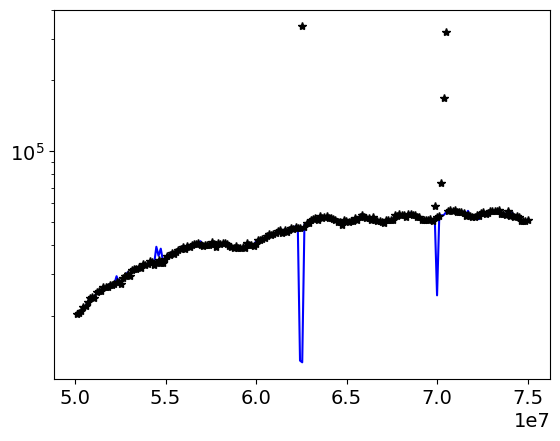

In [9]:

# plt.semilogy(F.freqs, np.mean(np.abs(F.data[key]),axis=0))
plt.plot(F_data.freqs, np.mean(np.abs(F_data.data[key]),axis=0),'b')
plt.semilogy(F_data.freqs, np.mean(np.abs(F_data_un.data[key]),axis=0),'k*')

NameError: name 'F' is not defined

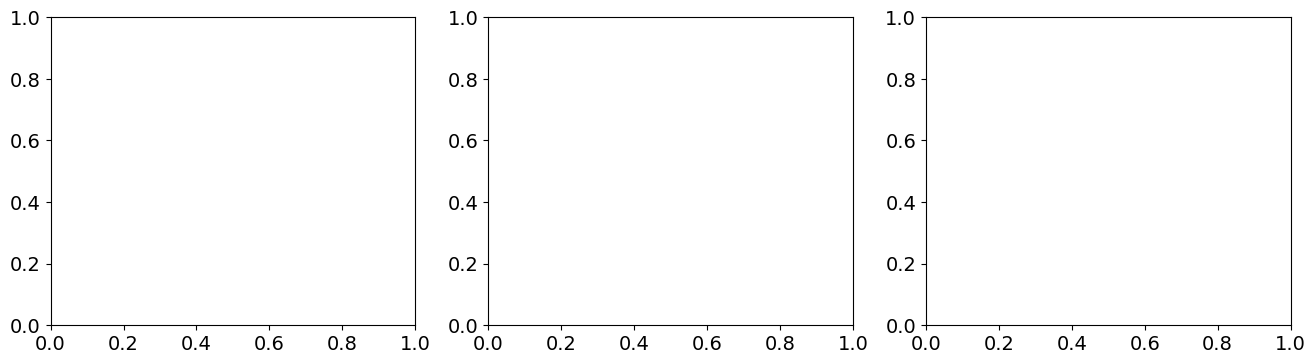

In [7]:

key = (3, 5, 'nn')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e7),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(5, -5)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e7),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])
ax.set_xlim(-500, 500)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e2),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

# cbax = fig.add_axes([0.83, 0.1, 0.1, 0.8])
# cbax.axis('off')
# cbar = fig.colorbar(cax, ax=cbax, label=r"$|V|$ [Jy]");

In [ ]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
mode="diffuse"
F_zero = hc.frf.FRFilter(path_data+"Filtered_model_"+filter_name+"_"+mode+"_vis_expanded_"+lsts_center+"_"+spw+".uvh5")
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_zero.read(bls=(3, 5, 'nn'))
# correct for improper conjugation in the simulated data
F_zero.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_zero.hd._determine_blt_slicing()
F_zero.hd._determine_pol_indexing()
F_zero.attach_data()

# take their Fourier transforms across frequency, time, and both axes
F_zero.fft_data(data=F_zero.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_zero.fft_data(data=F_zero.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_zero.fft_data(data=F_zero.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

Text(0, 0.5, 'fringe rate [mHz]')

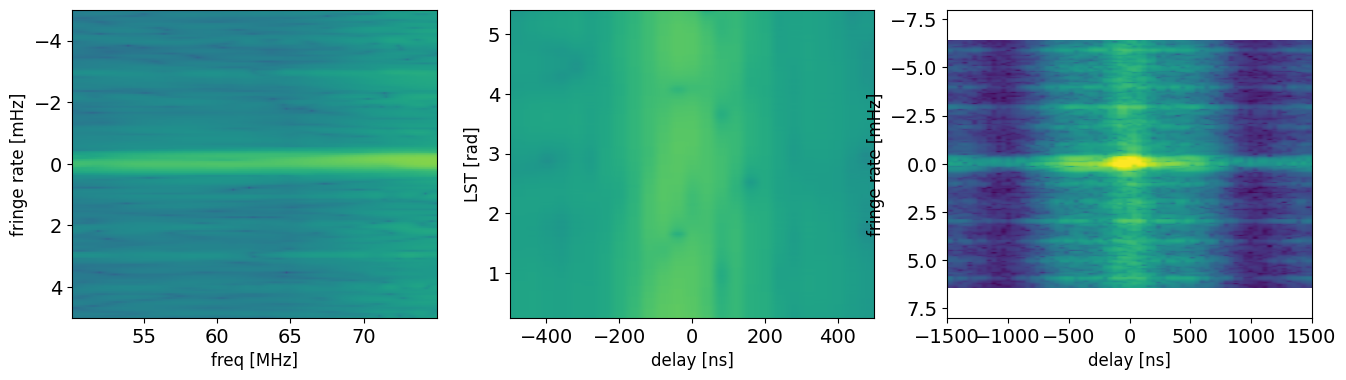

In [8]:
key = (3, 5, 'nn')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e7),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(5, -5)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e7),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])
ax.set_xlim(-500, 500)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e2),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

# cbax = fig.add_axes([0.83, 0.1, 0.1, 0.8])
# cbax.axis('off')
# cbar = fig.colorbar(cax, ax=cbax, label=r"$|V|$ [Jy]");

In [10]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
lsts_center="1h"
mode="diffuse"
F_zero = hc.frf.FRFilter(path_data+"Filtered_model_"+filter_name+"_"+mode+"_vis_expanded_"+lsts_center+"_"+spw+".uvh5")
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_zero.read(bls=(3, 5, 'nn'))
# correct for improper conjugation in the simulated data
F_zero.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_zero.hd._determine_blt_slicing()
F_zero.hd._determine_pol_indexing()
F_zero.attach_data()

# take their Fourier transforms across frequency, time, and both axes
F_zero.fft_data(data=F_zero.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_zero.fft_data(data=F_zero.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_zero.fft_data(data=F_zero.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

Text(0, 0.5, 'fringe rate [mHz]')

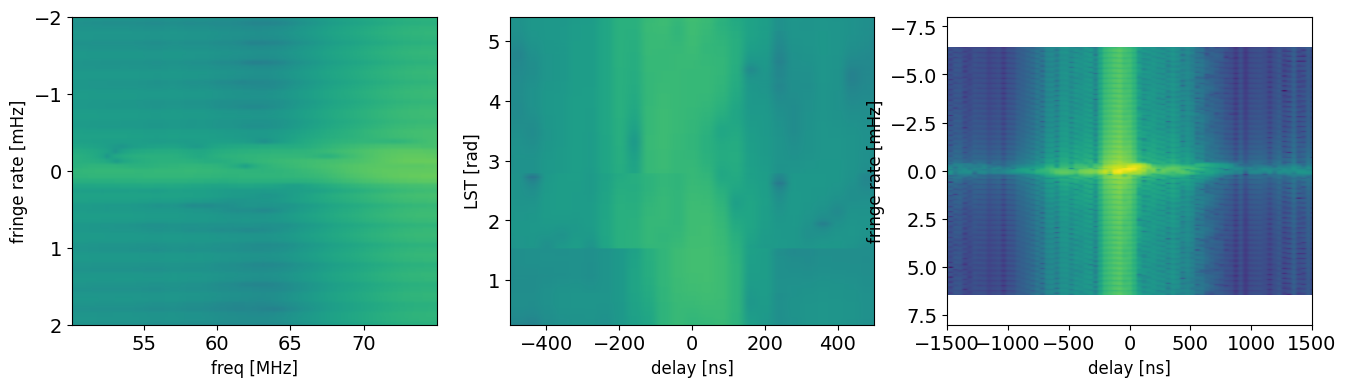

In [11]:
key = (3, 5, 'nn')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_zero.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e7),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(2, -2)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F_zero.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e7),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])
ax.set_xlim(-500, 500)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F_zero.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e2),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

# cbax = fig.add_axes([0.83, 0.1, 0.1, 0.8])
# cbax.axis('off')
# cbar = fig.colorbar(cax, ax=cbax, label=r"$|V|$ [Jy]");

KeyError: "Cannot find either (3, 10, 'ee') or (10, 3, 'ee') in this DataContainer."

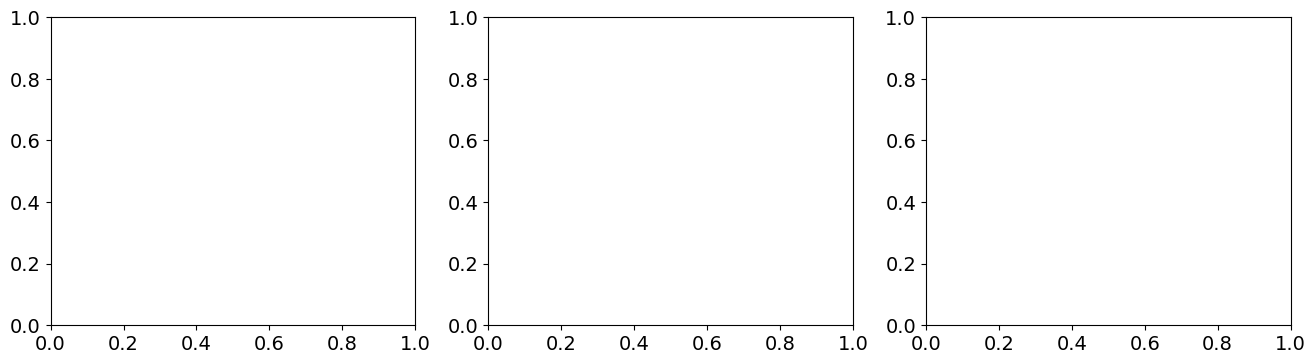

In [33]:
key = (3, 10, 'ee')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_zero.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e0),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)
ax.set_title("$|V_{zeroth}|$")

ax = axes[1]
ax.imshow(np.abs(F.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e0),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)
ax.set_title("$|V_{first}|$")

ax = axes[2]
ax.imshow(np.abs(F.d_both_fft[key]-F_zero.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e0),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)
ax.set_title("$|V_{first}-V_{zeroth}|$")

## Filtered data, F_25

In [8]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_25= hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_complete_filtered_data_dpss_25_non_redundancy_low_2h.uvh5')
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_25.read(polarizations=[-5])

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [9]:
# correct for improper conjugation in the simulated data
F_25.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_25.hd._determine_blt_slicing()
F_25.hd._determine_pol_indexing()
F_25.attach_data()

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [10]:
# take their Fourier transforms across frequency, time, and both axes
F_25.fft_data(data=F_25.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_25.fft_data(data=F_25.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_25.fft_data(data=F_25.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

Text(0, 0.5, 'fringe rate [mHz]')

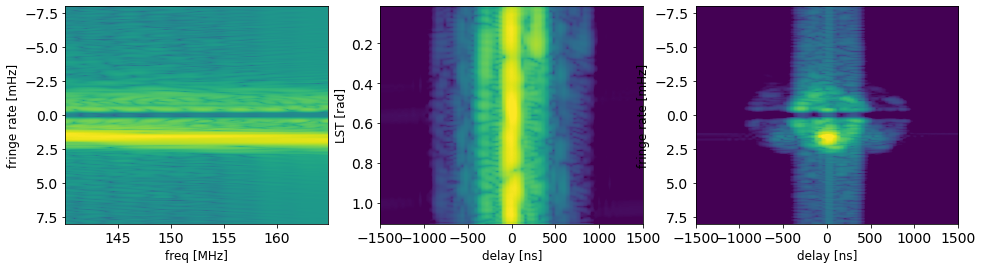

In [11]:
key = (3, 108, 'ee')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_25.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F_25.freqs[0]/1e6, F_25.freqs[-1]/1e6, F_25.frates[-1], F_25.frates[0]])
ax.set_ylim(8, -8)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F_25.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-5, vmax=1e1),
          extent=[F_25.delays[0], F_25.delays[-1], F_25.lsts[-1], F_25.lsts[0]])
ax.set_xlim(-1500, 1500)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F_25.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e0),
          extent=[F_25.delays[0], F_25.delays[-1], F_25.frates[-1], F_25.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

## Main lobe 

In [12]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_MA= hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_complete_filtered_Gaussian_non_redundant_low_2h.uvh5')
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_MA.read(polarizations=[-5])                      

F_MA.read(polarizations=[-5])
# correct for improper conjugation in the simulated data
F_MA.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_MA.hd._determine_blt_slicing()
F_MA.hd._determine_pol_indexing()
F_MA.attach_data()

# take their Fourier transforms across frequency, time, and both axes
F_MA.fft_data(data=F.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_MA.fft_data(data=F.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_MA.fft_data(data=F.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does n

Text(0, 0.5, 'fringe rate [mHz]')

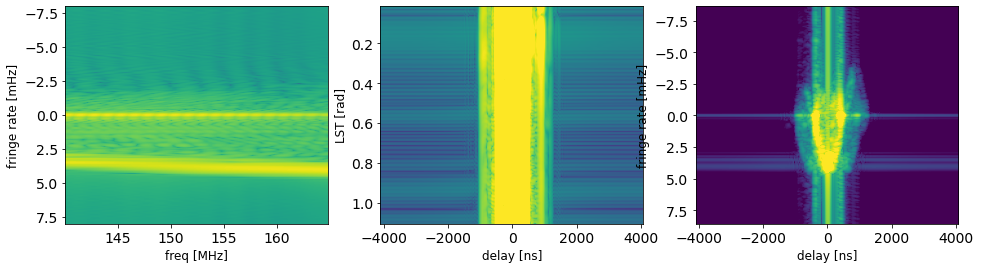

In [13]:
key = (27, 48, 'ee')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_MA.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(8, -8)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F_MA.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e-2),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])

ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F_MA.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e-2),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])

ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

In [14]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_MA_02= hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_complete_filtered_Gaussian_non_redundant_low_2h_test.uvh5')
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_MA_02.read(polarizations=[-5])   


F_MA_02.read(polarizations=[-5])
# correct for improper conjugation in the simulated data
F_MA_02.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_MA_02.hd._determine_blt_slicing()
F_MA_02.hd._determine_pol_indexing()
F_MA_02.attach_data()

# take their Fourier transforms across frequency, time, and both axes
F_MA_02.fft_data(data=F.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_MA_02.fft_data(data=F.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_MA_02.fft_data(data=F.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994858716 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does n

Text(0, 0.5, 'fringe rate [mHz]')

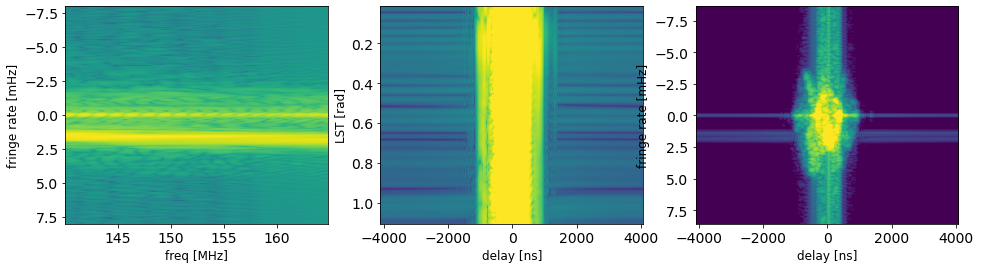

In [15]:
key = (3, 108, 'ee')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_MA_02.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(8, -8)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F_MA_02.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e-2),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])

ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F_MA_02.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e-2),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])

ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

This figure shows the foreground visibility in frequency, LST, delay and fringe-rate spaces. In Fourier space (i.e. delay and/or fringe-rate space) we see the foreground structure is generally more compact. Remember the first notebook which showed how different sky signals occupy these spaces, which is also dependent on the baseline orientation. Next we will apply a simple time-domain filter (or a fringe-rate filter) on the data.

## F_40 mHz

In [16]:
# # Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
# F_40 = hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_complete_filtered_data_dpss_40_non_redundancy_low_2h.uvh5')
# #F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
# F_40.read(polarizations=[-5])

# # correct for improper conjugation in the simulated data
# F_40.hd.conjugate_bls()
# # everything below is just internal book-keeping after updating the conjugation
# F_40.hd._determine_blt_slicing()
# F_40.hd._determine_pol_indexing()
# F_40.attach_data()

# # take their Fourier transforms across frequency, time, and both axes
# F_40.fft_data(data=F_40.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
# F_40.fft_data(data=F_40.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
# F_40.fft_data(data=F_40.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

In [17]:

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ax = axes[0]
# ax.imshow(np.abs(F_40.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-3, vmax=1e1),
#           extent=[F_25.freqs[0]/1e6, F_25.freqs[-1]/1e6, F_25.frates[-1], F_25.frates[0]])
# ax.set_xlim(150, 168); ax.set_ylim(8, -8)
# ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

# ax = axes[1]
# ax.imshow(np.abs(F_40.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-5, vmax=1e1),
#           extent=[F_25.delays[0], F_25.delays[-1], F_25.lsts[-1], F_25.lsts[0]])
# ax.set_xlim(-1500, 1500)
# ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

# ax = axes[2]
# ax.imshow(np.abs(F_40.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e0),
#           extent=[F_25.delays[0], F_25.delays[-1], F_25.frates[-1], F_25.frates[0]])
# ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
# ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

## F_60 mHz

In [18]:
# # Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
# F_60 = hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_complete_filtered_data_dpss_60_non_redundancy_low_2h.uvh5')
# #F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
# F_60.read(polarizations=[-5])

# # correct for improper conjugation in the simulated data
# F_60.hd.conjugate_bls()
# # everything below is just internal book-keeping after updating the conjugation
# F_60.hd._determine_blt_slicing()
# F_60.hd._determine_pol_indexing()
# F_60.attach_data()

# # take their Fourier transforms across frequency, time, and both axes
# F_60.fft_data(data=F_60.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
# F_60.fft_data(data=F_60.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
# F_60.fft_data(data=F_60.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

In [19]:

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ax = axes[0]
# ax.imshow(np.abs(F_60.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-3, vmax=1e1),
#           extent=[F_25.freqs[0]/1e6, F_25.freqs[-1]/1e6, F_25.frates[-1], F_25.frates[0]])
# ax.set_xlim(150, 168); ax.set_ylim(8, -8)
# ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

# ax = axes[1]
# ax.imshow(np.abs(F_60.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-5, vmax=1e1),
#           extent=[F_25.delays[0], F_25.delays[-1], F_25.lsts[-1], F_25.lsts[0]])
# ax.set_xlim(-1500, 1500)
# ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

# ax = axes[2]
# ax.imshow(np.abs(F_60.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e0),
#           extent=[F_25.delays[0], F_25.delays[-1], F_25.frates[-1], F_25.frates[0]])
# ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
# ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

## main-lobe filter 

In [20]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_G_1mHz = hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_first_order_Gaussian_low.uvh5')
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_G_1mHz.read(polarizations=[-5])

# correct for improper conjugation in the simulated data
F_G_1mHz.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_G_1mHz.hd._determine_blt_slicing()
F_G_1mHz.hd._determine_pol_indexing()
F_G_1mHz.attach_data()

# take their Fourier transforms across frequency, time, and both axes
F_G_1mHz.fft_data(data=F_G_1mHz.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_G_1mHz.fft_data(data=F_G_1mHz.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_G_1mHz.fft_data(data=F_G_1mHz.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994857206 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994857206 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994857206 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


Text(0, 0.5, 'fringe rate [mHz]')

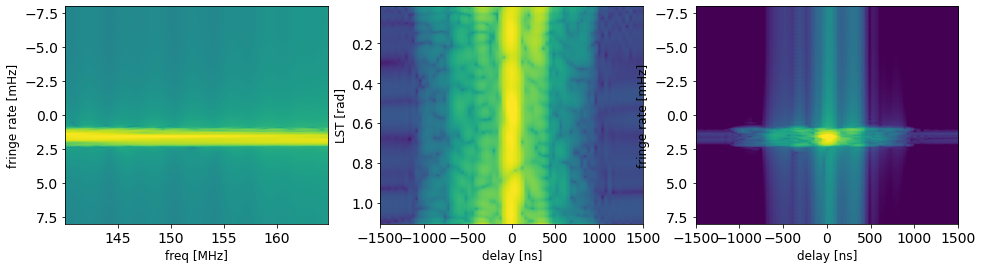

In [21]:
key = (3, 108, 'ee')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_G_1mHz.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(8, -8)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F_G_1mHz.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])
ax.set_xlim(-1500, 1500)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F_G_1mHz.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e0),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

In [22]:
# Load some sample visibilities. Note that frf.FRFilter is a subclass of vis_clean.VisClean!
F_G_2mHz = hc.frf.FRFilter('/net/sinatra/vault-ike/ntsikelelo/Simulated_data_files/UVH5_files/Model_first_order_25mHz_dpss_non_redundancy_low_2h.uvh5')
#F = hc.frf.FRFilter('/home/ntsikelelo/Simulated_data_files/UVH5_files/zen.LST.05.00513.uvh5')
F_G_2mHz.read(polarizations=[-5])

# correct for improper conjugation in the simulated data
F_G_2mHz.hd.conjugate_bls()
# everything below is just internal book-keeping after updating the conjugation
F_G_2mHz.hd._determine_blt_slicing()
F_G_2mHz.hd._determine_pol_indexing()
F_G_2mHz.attach_data()

# take their Fourier transforms across frequency, time, and both axes
F_G_2mHz.fft_data(data=F_G_2mHz.data, assign='d_freq_fft', ax='freq', window='bh', overwrite=True, ifft=True)
F_G_2mHz.fft_data(data=F_G_2mHz.data, assign='d_time_fft', ax='time', window='bh', overwrite=True, ifft=True)
F_G_2mHz.fft_data(data=F_G_2mHz.data, assign='d_both_fft', ax='both', window='bh', overwrite=True, ifft=True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994857206 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994857206 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 1.3999999994857206 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


Text(0, 0.5, 'fringe rate [mHz]')

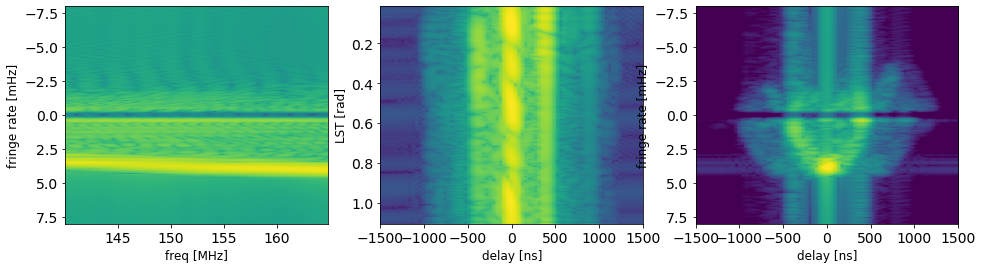

In [23]:
key = (27, 48, 'ee')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.imshow(np.abs(F_G_2mHz.d_time_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F.freqs[0]/1e6, F.freqs[-1]/1e6, F.frates[-1], F.frates[0]])
ax.set_xlim(F.freqs[0]/1e6,  F.freqs[-1]/1e6); ax.set_ylim(8, -8)
ax.set_xlabel('freq [MHz]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

ax = axes[1]
ax.imshow(np.abs(F_G_2mHz.d_freq_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e1),
          extent=[F.delays[0], F.delays[-1], F.lsts[-1], F.lsts[0]])
ax.set_xlim(-1500, 1500)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('LST [rad]', fontsize=12)

ax = axes[2]
ax.imshow(np.abs(F_G_2mHz.d_both_fft[key]), aspect='auto', norm=matplotlib.colors.LogNorm(vmin=1e-7, vmax=1e0),
          extent=[F.delays[0], F.delays[-1], F.frates[-1], F.frates[0]])
ax.set_xlim(-1500, 1500); ax.set_ylim(8, -8)
ax.set_xlabel('delay [ns]', fontsize=12); ax.set_ylabel('fringe rate [mHz]', fontsize=12)

(260,)


(0.0, 1.0)

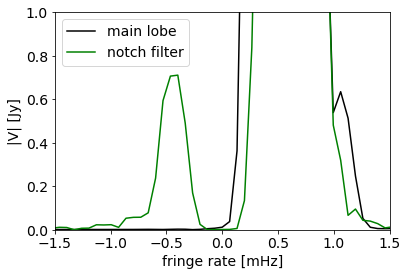

In [32]:
key=(3, 42, 'ee')
c0=np.abs(F.d_time_fft[key])[:,0]
c1=np.abs(F_G_1mHz.d_time_fft[key])[:,0]
c2=np.abs(F_G_2mHz.d_time_fft[key])[:,0]
x=F_G_1mHz.frates
print(c1.shape)

plt.figure()
# plt.plot(x,np.abs(c0),'c',label='no filter')
plt.plot(x,np.abs(c1),'k',label='main lobe')
plt.plot(x,np.abs(c2),'g',label='notch filter')
plt.legend()
plt.xlabel("fringe rate [mHz]")
plt.ylabel("|V| [Jy]")
plt.xlim([-1.5,1.5])
plt.ylim([0,1])

(260,)


(0.0, 2.0)

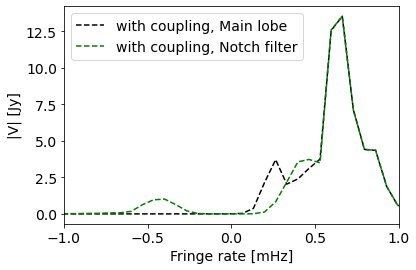

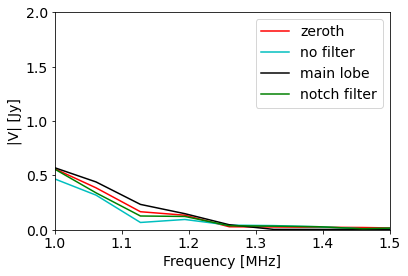

In [37]:
n=13
N=3
c0_first=np.abs(F.d_time_fft[key])[:,0]
c01=np.mean(np.abs(F_zero.d_time_fft[key])[:,N:n],axis=1)
c0=np.mean(np.abs(F_MA.d_time_fft[key])[:,N:n],axis=1)
c00=np.mean(np.abs(F_25.d_time_fft[key])[:,N:n],axis=1)
c1=np.mean(np.abs(F_G_1mHz.d_time_fft[key])[:,N:n],axis=1)
c2=np.mean(np.abs(F_G_2mHz.d_time_fft[key])[:,N:n],axis=1)
x=F_G_1mHz.frates
print(c1.shape)

# plt.figure()
# plt.plot(x,np.abs(c01),'r',label='zeroth')
# plt.plot(x,np.abs(c0_first),'c',label='no filter')
# plt.plot(x,np.abs(c0),'k',label='zeroth, main lobe filter')
# plt.plot(x,np.abs(c00),'g',label='zeroth, notch lobe filter')
# # plt.plot(x,np.abs(c1),'--k',label='first, main lobe')
# # plt.plot(x,np.abs(c2),'--g',label='first, notch filter')
# plt.legend()
# plt.xlabel("Frequency [MHz]")
# plt.ylabel("|V| [Jy]")
# plt.xlim([-2,2])


plt.figure()
# plt.plot(x,np.abs(c01),'r',label='zeroth')
# plt.plot(x,np.abs(c0),'k',label='zeroth, main lobe filter')
# plt.plot(x,np.abs(c00),'g',label='zeroth, notch lobe filter')
# plt.plot(x,np.abs(c01),'r',label='zeroth')
# plt.plot(x,np.abs(c0_first),'c',label='no filter')
plt.plot(x,np.abs(c1),'--k',label='with coupling, Main lobe')
plt.plot(x,np.abs(c2),'--g',label='with coupling, Notch filter')
plt.legend()
plt.xlabel("Fringe rate [mHz]")
plt.ylabel("|V| [Jy]")
plt.xlim([-1,1])

plt.figure()
plt.plot(x,np.abs(c01),'r',label='zeroth')
plt.plot(x,np.abs(c0_first),'c',label='no filter')
plt.plot(x,np.abs(c1),'k',label='main lobe')
plt.plot(x,np.abs(c2),'g',label='notch filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
plt.xlim([1,1.5])
plt.ylim([0,2])

(260,)


(0.0, 4.0)

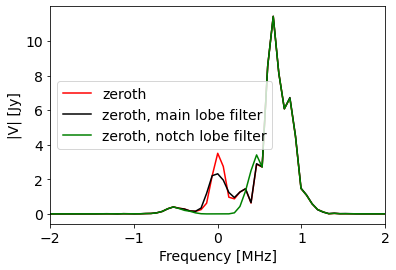

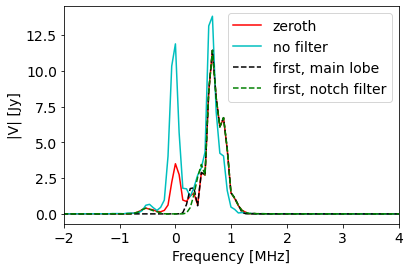

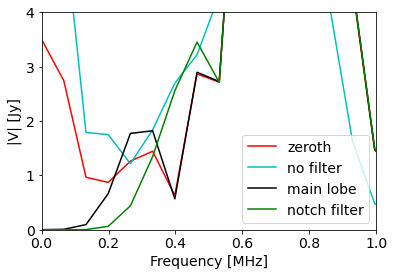

In [34]:
n=128
N=118
c0_first=np.abs(F.d_time_fft[key])[:,0]
c01=np.mean(np.abs(F_zero.d_time_fft[key])[:,N:n],axis=1)
c0=np.mean(np.abs(F_MA.d_time_fft[key])[:,N:n],axis=1)
c00=np.mean(np.abs(F_25.d_time_fft[key])[:,N:n],axis=1)
c1=np.mean(np.abs(F_G_1mHz.d_time_fft[key])[:,N:n],axis=1)
c2=np.mean(np.abs(F_G_2mHz.d_time_fft[key])[:,N:n],axis=1)
x=F_G_1mHz.frates
print(c1.shape)

plt.figure()
plt.plot(x,np.abs(c01),'r',label='zeroth')
plt.plot(x,np.abs(c0),'k',label='zeroth, main lobe filter')
plt.plot(x,np.abs(c00),'g',label='zeroth, notch lobe filter')
# plt.plot(x,np.abs(c1),'--k',label='first, main lobe')
# plt.plot(x,np.abs(c2),'--g',label='first, notch filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
plt.xlim([-2,2])


plt.figure()
plt.plot(x,np.abs(c01),'r',label='zeroth')
plt.plot(x,np.abs(c0_first),'c',label='no filter')
# plt.plot(x,np.abs(c01),'r',label='zeroth')
# plt.plot(x,np.abs(c0),'k',label='zeroth, main lobe filter')
# plt.plot(x,np.abs(c00),'g',label='zeroth, notch lobe filter')
plt.plot(x,np.abs(c1),'--k',label='first, main lobe')
plt.plot(x,np.abs(c2),'--g',label='first, notch filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
plt.xlim([-2,4])

plt.figure()
plt.plot(x,np.abs(c01),'r',label='zeroth')
plt.plot(x,np.abs(c0_first),'c',label='no filter')
plt.plot(x,np.abs(c1),'k',label='main lobe')
plt.plot(x,np.abs(c2),'g',label='notch filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
plt.xlim([0,1])
plt.ylim([0,4])

(204,)


Text(0, 0.5, '|V| [Jy]')

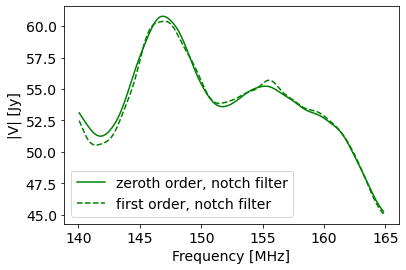

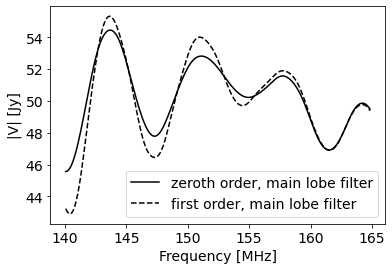

In [35]:
time_n=120


c_zero=np.abs(F_zero.data[key])[time_n,:]

c_first=np.abs(F.data[key])[time_n,:]

c0=np.abs(F_25.data[key])[time_n,:]
c1=np.abs(F_G_2mHz.data[key])[time_n,:]
c2=np.abs(F_MA.data[key])[time_n,:]
c3=np.abs(F_G_1mHz.data[key])[time_n,:]
freqs=F_G_1mHz.freqs*1e-6
print(c1.shape)

plt.figure()
# plt.plot(freqs,np.abs(c_zero),'c',label='zeroth, no filter')
# plt.plot(freqs,np.abs(c_first),'--c',label='first, no filter')
plt.plot(freqs,np.abs(c0),'g',label='zeroth order, notch filter')
plt.plot(freqs,np.abs(c1),'--g',label='first order, notch filter')
# plt.plot(freqs,np.abs(c2),'k',label='zeroth, main lobe filter')
# plt.plot(freqs,np.abs(c3),'k--',label='first, main lobe filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
# plt.xlim([-2,2])


plt.figure()
# plt.plot(freqs,np.abs(c_zero),'c',label='zeroth, no filter')
# plt.plot(freqs,np.abs(c_first),'--c',label='first, no filter')
# plt.plot(freqs,np.abs(c0),'g',label='zeroth, notch filter')
# plt.plot(freqs,np.abs(c1),'--g',label='first, notch filter')
plt.plot(freqs,np.abs(c2),'k',label='zeroth order, main lobe filter')
plt.plot(freqs,np.abs(c3),'k--',label='first order, main lobe filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
# plt.xlim([-2,2])

(204,)


Text(0, 0.5, '|V| [Jy]')

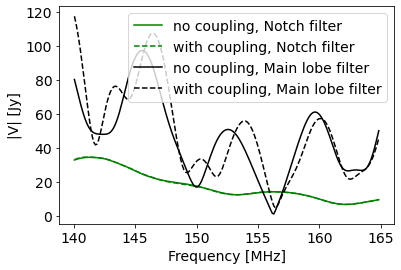

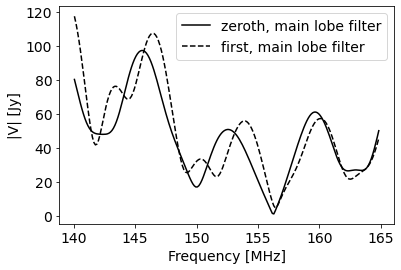

In [36]:
time_n=3


c_zero=np.abs(F_zero.data[key])[time_n,:]

c_first=np.abs(F.data[key])[time_n,:]

c0=np.abs(F_25.data[key])[time_n,:]
c1=np.abs(F_G_2mHz.data[key])[time_n,:]
c2=np.abs(F_MA.data[key])[time_n,:]
c3=np.abs(F_G_1mHz.data[key])[time_n,:]
freqs=F_G_1mHz.freqs*1e-6
print(c1.shape)

plt.figure()
# plt.plot(freqs,np.abs(c_zero),'c',label='zeroth, no filter')
# plt.plot(freqs,np.abs(c_first),'--c',label='first, no filter')
plt.plot(freqs,np.abs(c0),'g',label='no coupling, Notch filter')
plt.plot(freqs,np.abs(c1),'--g',label='with coupling, Notch filter')
plt.plot(freqs,np.abs(c2),'k',label='no coupling, Main lobe filter')
plt.plot(freqs,np.abs(c3),'k--',label='with coupling, Main lobe filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
# plt.xlim([-2,2])

plt.figure()
# plt.plot(freqs,np.abs(c_zero),'c',label='zeroth, no filter')
# plt.plot(freqs,np.abs(c_first),'--c',label='first, no filter')
# plt.plot(freqs,np.abs(c0),'g',label='zeroth, notch filter')
# plt.plot(freqs,np.abs(c1),'--g',label='first, notch filter')
plt.plot(freqs,np.abs(c2),'k',label='zeroth, main lobe filter')
plt.plot(freqs,np.abs(c3),'k--',label='first, main lobe filter')
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("|V| [Jy]")
# plt.xlim([-2,2])

0.22280242852297785 0.0012672930178897917
(13,)
-0.23421149724589252 0.0022857678593456573
(14,)
-0.29872449768520765 0.0033004451530035555
(18,)


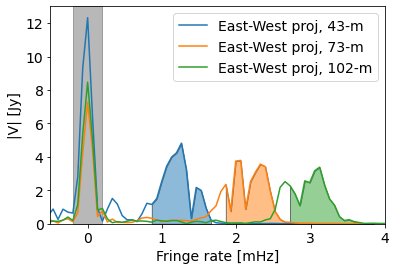

In [29]:
bls_list=np.array([(3, 42, 'ee'),(3, 5, 'ee'),(3, 7, 'ee')])
bls_dic_list={}
sigma=np.load("/home/ntsikelelo/non_redundancy_sim/sigma_gaussian_low.npy",allow_pickle=True).item()
f_value=np.load("/home/ntsikelelo/non_redundancy_sim/fringe_value_gaussian_low.npy",allow_pickle=True).item()
bls_E_W=np.load("/home/ntsikelelo/non_redundancy_sim/E_W_baseline_gaussian_low.npy",allow_pickle=True).item()
for k in sigma:
    if k==(50, 53, 'ee'):
        bls_dic_list[k]=sigma[k]
    if k==(50, 55, 'ee'):
        bls_dic_list[k]=sigma[k]
    if k==(50, 57, 'ee'):
        bls_dic_list[k]=sigma[k]    
n=13
N=3




i=0
for key in bls_dic_list:
    cl=np.array(['k','r','b'])
    print(sigma[key],np.abs(f_value[key]))
    c1=np.mean(np.abs(F.d_time_fft[key])[:,0:1],axis=1)
    x=F_G_1mHz.frates
    f=np.abs(f_value[key])*1e3
    x_values=np.ones(x.shape)*(f-2*np.abs(sigma[key]))
    x2_values=np.ones(x.shape)*(f+2*np.abs(sigma[key]))
    y_values=np.linspace(0,15,x.shape[0])
    plt.plot(x,np.abs(c1),label="East-West proj, "+str(int(bls_E_W[key]))+"-m")
    y2=np.abs(c1)[(x>x_values[0])&(x<x2_values[0])]
    print(y2.shape)
#     plt.plot(x_values,y_values,'--'+cl[i])
#     plt.plot(x2_values,y_values,'--'+cl[i])
    plt.fill_between(x[(x>x_values[0])&(x<x2_values[0])], 0,y2 , alpha=0.5, edgecolor='k')
#     plt.fill_between(x[(x>-0.25)&(x<0.25)], 0, 12, color='none', hatch='X', edgecolor='k')
    plt.fill_between(x[(x>-.25)&(x<.25)], 0, 13, color='k', alpha=0.1)
    plt.legend()
    plt.xlabel("Fringe rate [mHz]")
    plt.ylabel("|V| [Jy]")
    plt.xlim([-0.5,4])
    plt.ylim([0,13])
    i=i+1

In [30]:
plt.fill_between?